In [1]:
# ==============================
# Install required packages
# ==============================
!pip install -q scvelo umap-learn  # scvelo for data, umap for its internals
!pip install -q git+https://github.com/theislab/scvelo.git   # latest scvelo (optional)
# (TensorFlow & other libraries are already available in Colab)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.2/191.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confl

In [2]:
# ==============================
# Imports
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Permute, Conv1D, Reshape, LayerNormalization,
    MultiHeadAttention, Add, Layer, LSTM, GRU, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import scvelo as scv
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# ===================================================
#  Rubick_Attention_Block
# ===================================================
class Rubick_Attention_Block(layers.Layer):
    def __init__(self, n_heads=1, multi_layer=False, use_residual=True,
                 use_scaling=True, soft_max_axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.multi_layer = multi_layer
        self.use_residual = use_residual
        self.use_scaling = use_scaling
        self.soft_max_axis = soft_max_axis

    def build(self, input_shape):
        self.features = input_shape[-1]
        self.W = self.add_weight(shape=(self.features, self.features),
                                 initializer="glorot_uniform", trainable=True, name="att_weight")
        self.b = self.add_weight(shape=(self.features,), initializer="zeros",
                                 trainable=True, name="att_bias")
        self.c = self.add_weight(shape=(self.n_heads, self.features, self.features),
                                 initializer="glorot_uniform", trainable=True, name="context_vector")
        if self.multi_layer and self.n_heads > 1:
            self.head_weights = self.add_weight(shape=(self.n_heads,), initializer="ones",
                                                trainable=True, name="head_weights")
        if not self.multi_layer and self.n_heads > 1:
            self.output_projection = self.add_weight(
                shape=(self.n_heads * self.features, self.features),
                initializer="glorot_uniform", trainable=True, name="output_projection")
            self.output_bias = self.add_weight(shape=(self.features,), initializer="zeros",
                                               trainable=True, name="output_bias")
        if self.use_residual and not self.multi_layer:
            self.layer_norm = LayerNormalization(epsilon=1e-6)
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        c_it = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        scale = tf.sqrt(tf.cast(self.features, tf.float32)) if self.use_scaling else 1.0

        if self.multi_layer:
            if self.n_heads == 1:
                a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
                a_it_softmax = tf.nn.softmax(a_it, axis=-1)
                return x * a_it_softmax
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)
            x_expanded = tf.expand_dims(x, axis=1)
            weighted_all = x_expanded * a_it_softmax_all
            if hasattr(self, 'head_weights'):
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            weighted_reshaped = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]),
                [batch_size, seq_len, self.n_heads * self.features])
            output = tf.nn.softmax(weighted_reshaped, axis=self.soft_max_axis)
            return output

        # non-multi-layer
        if self.n_heads == 1:
            a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
            a_it_softmax = tf.nn.softmax(a_it, axis=-1)
            output = x * a_it_softmax
        else:
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)
            x_expanded = tf.expand_dims(x, axis=1)
            weighted_all = x_expanded * a_it_softmax_all
            if hasattr(self, 'head_weights'):
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            concatenated = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]),
                [batch_size, seq_len, self.n_heads * self.features])
            output = tf.tensordot(concatenated, self.output_projection, axes=1) + self.output_bias
            output = tf.nn.relu(output)
            output = tf.nn.softmax(output, axis=self.soft_max_axis)

        if self.use_residual:
            output = output + x
        if hasattr(self, 'layer_norm'):
            output = self.layer_norm(output)
        return output

    def compute_output_shape(self, input_shape):
        if self.multi_layer:
            if self.n_heads == 1:
                return input_shape
            else:
                return (input_shape[0], input_shape[1], self.n_heads * input_shape[2])
        else:
            return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_heads': self.n_heads,
            'multi_layer': self.multi_layer,
            'use_residual': self.use_residual,
            'use_scaling': self.use_scaling,
            'soft_max_axis': self.soft_max_axis
        })
        return config

# ===================================================
#  Rubick_Attention_Block (better for longer horizons)
# ===================================================
class Rubick_Attention_Block(layers.Layer):
    def __init__(self, n_heads=1, multi_layer=False, use_residual=True,
                 use_scaling=True, soft_max_axis=-1,
                 sinkhorn_iters=0,          # 0 = no Sinkhorn
                 hard_gating=False,         # apply copy & multiply
                 **kwargs):
        super().__init__(**kwargs)
        self.n_heads = n_heads
        self.multi_layer = multi_layer
        self.use_residual = use_residual
        self.use_scaling = use_scaling
        self.soft_max_axis = soft_max_axis
        self.sinkhorn_iters = sinkhorn_iters
        self.hard_gating = hard_gating

    def build(self, input_shape):
        self.features = input_shape[-1]
        self.W = self.add_weight(shape=(self.features, self.features),
                                 initializer="glorot_uniform", trainable=True, name="att_weight")
        self.b = self.add_weight(shape=(self.features,), initializer="zeros",
                                 trainable=True, name="att_bias")
        self.c = self.add_weight(shape=(self.n_heads, self.features, self.features),
                                 initializer="glorot_uniform", trainable=True, name="context_vector")
        if self.multi_layer and self.n_heads > 1:
            self.head_weights = self.add_weight(shape=(self.n_heads,), initializer="ones",
                                                trainable=True, name="head_weights")
        if not self.multi_layer and self.n_heads > 1:
            self.output_projection = self.add_weight(
                shape=(self.n_heads * self.features, self.features),
                initializer="glorot_uniform", trainable=True, name="output_projection")
            self.output_bias = self.add_weight(shape=(self.features,), initializer="zeros",
                                               trainable=True, name="output_bias")
        if self.use_residual and not self.multi_layer:
            self.layer_norm = layers.LayerNormalization(epsilon=1e-6)
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        c_it = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        scale = tf.sqrt(tf.cast(self.features, tf.float32)) if self.use_scaling else 1.0

        if self.multi_layer:
            if self.n_heads == 1:
                a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
                a_it_softmax = tf.nn.softmax(a_it, axis=-1)
                return x * a_it_softmax
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)
            x_expanded = tf.expand_dims(x, axis=1)
            weighted_all = x_expanded * a_it_softmax_all
            if hasattr(self, 'head_weights'):
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            weighted_reshaped = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]),
                [batch_size, seq_len, self.n_heads * self.features])
            output = tf.nn.softmax(weighted_reshaped, axis=self.soft_max_axis)
            return output

        # non-multi-layer
        if self.n_heads == 1:
            a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
            a_it_softmax = tf.nn.softmax(a_it, axis=-1)
            output = x * a_it_softmax
        else:
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)
            x_expanded = tf.expand_dims(x, axis=1)
            weighted_all = x_expanded * a_it_softmax_all
            if hasattr(self, 'head_weights'):
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            concatenated = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]),
                [batch_size, seq_len, self.n_heads * self.features])
            output = tf.tensordot(concatenated, self.output_projection, axes=1) + self.output_bias
            output = tf.nn.relu(output)

            # ------- Softmax + optional doubly stochastic + hard gating -------
            output = tf.nn.softmax(output, axis=self.soft_max_axis)

            # Optional: Sinkhorn normalisation to make it doubly stochastic
            if self.sinkhorn_iters > 0:
                output = self._sinkhorn(output, self.sinkhorn_iters)

            # Optional: copy with max → 1 and element‑wise multiply
            if self.hard_gating:
                # find the position of the maximum in each row
                max_idx = tf.argmax(output, axis=-1)
                mask = tf.one_hot(max_idx, depth=tf.shape(output)[-1])
                # copy where max becomes 1, others keep original value
                copy = output * (1.0 - mask) + 1.0 * mask
                output = output * copy
            # ----------------------------------------------------------------

        if self.use_residual:
            output = output + x
        if hasattr(self, 'layer_norm'):
            output = self.layer_norm(output)
        return output

    def _sinkhorn(self, M, n_iter=10):
        """Sinkhorn–Knopp normalisation to obtain a doubly stochastic matrix."""
        for _ in range(n_iter):
            # normalise columns
            col_sum = tf.reduce_sum(M, axis=-2, keepdims=True) + 1e-8
            M = M / col_sum
            # normalise rows
            row_sum = tf.reduce_sum(M, axis=-1, keepdims=True) + 1e-8
            M = M / row_sum
        return M

    def compute_output_shape(self, input_shape):
        if self.multi_layer:
            if self.n_heads == 1:
                return input_shape
            else:
                return (input_shape[0], input_shape[1], self.n_heads * input_shape[2])
        else:
            return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_heads': self.n_heads,
            'multi_layer': self.multi_layer,
            'use_residual': self.use_residual,
            'use_scaling': self.use_scaling,
            'soft_max_axis': self.soft_max_axis,
            'sinkhorn_iters': self.sinkhorn_iters,
            'hard_gating': self.hard_gating,
        })
        return config

In [4]:
# ===================================================
#  PerChannelActivation
# ===================================================
class PerChannelActivation(layers.Layer):
    def __init__(self, activation_type='elu', **kwargs):
        super().__init__(**kwargs)
        self.activation_type = activation_type

    def build(self, input_shape):
        self.num_channels = input_shape[1]   # after Permute
        if self.activation_type == 'pelu':
            self.alpha = self.add_weight(name='alpha', shape=(self.num_channels,),
                                         initializer='ones', trainable=True)
            self.beta = self.add_weight(name='beta', shape=(self.num_channels,),
                                        initializer='ones', trainable=True)
        elif self.activation_type == 'prelu':
            self.alpha = self.add_weight(name='alpha', shape=(self.num_channels,),
                                         initializer=tf.keras.initializers.Constant(0.1),
                                         trainable=True)
        elif self.activation_type == 'pswish':
            self.beta = self.add_weight(name='beta', shape=(self.num_channels,),
                                        initializer='ones', trainable=True)
        elif self.activation_type == 'mix':
            self.weights = self.add_weight(name='weights', shape=(self.num_channels, 3),
                                           initializer='ones', trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        if self.activation_type == 'pelu':
            alpha = tf.expand_dims(self.alpha, axis=0)
            alpha = tf.expand_dims(alpha, axis=-1)
            beta = tf.expand_dims(self.beta, axis=0)
            beta = tf.expand_dims(beta, axis=-1)
            return tf.where(inputs >= 0, beta * inputs, alpha * (tf.exp(inputs) - 1))
        elif self.activation_type == 'prelu':
            alpha = tf.expand_dims(self.alpha, axis=0)
            alpha = tf.expand_dims(alpha, axis=-1)
            return tf.where(inputs >= 0, inputs, alpha * inputs)
        elif self.activation_type == 'pswish':
            beta = tf.expand_dims(self.beta, axis=0)
            beta = tf.expand_dims(beta, axis=-1)
            return inputs * tf.nn.sigmoid(beta * inputs)
        elif self.activation_type == 'mix':
            weights = tf.nn.softmax(self.weights, axis=-1)
            weights = tf.expand_dims(weights, axis=0)
            weights = tf.expand_dims(weights, axis=-1)
            relu_out = tf.nn.relu(inputs)
            sigmoid_out = tf.nn.sigmoid(inputs)
            tanh_out = tf.nn.tanh(inputs)
            activations = tf.stack([relu_out, sigmoid_out, tanh_out], axis=-1)
            weighted = tf.reduce_sum(weights * activations, axis=-1)
            return weighted
        return inputs

    def compute_output_shape(self, input_shape):
        return input_shape


# ===================================================
#  Rubick_Attention_Model (gene‑expression version)
# ===================================================
def Rubick_Attention_Model(
    input_len=40, pred_len=20, num_features=100,
    n_layer_rubickattention=3, n_heads_rubickattention=8,
    use_scaling_rubickattention=True,
    use_residual_rubickattention=True,
    dropout=0.1, dd_model=256, conv_size=7
):
    print(f"[DEBUG] RubickAttention: input=({input_len},{num_features}), pred_len={pred_len}")
    inputs = layers.Input(shape=(input_len, num_features), name='main_input')
    x = inputs

    # RubickAttention blocks (no reshaping)
    if n_layer_rubickattention <= 1:
        x = Rubick_Attention_Block(n_heads=n_heads_rubickattention, multi_layer=False,
                                   use_residual=use_residual_rubickattention,
                                   use_scaling=use_scaling_rubickattention,
                                   soft_max_axis=-2)(x)
    else:
        for i in range(1, n_layer_rubickattention):
            soft_max_axis = -1 if i % 2 == 0 else -2
            if n_heads_rubickattention > 1:
                x_multi = Rubick_Attention_Block(n_heads=n_heads_rubickattention,
                                                 multi_layer=True, use_residual=False,
                                                 use_scaling=use_scaling_rubickattention,
                                                 soft_max_axis=soft_max_axis)(x)
                x_proj = Dense(num_features, activation='relu', name=f'proj_{i}')(x_multi)
                x = Add()([x, x_proj])
            else:
                x = Rubick_Attention_Block(n_heads=n_heads_rubickattention,
                                           multi_layer=True,
                                           use_residual=use_residual_rubickattention,
                                           use_scaling=use_scaling_rubickattention,
                                           soft_max_axis=soft_max_axis)(x)

    # Output head
    print(f"[DEBUG] Before output head, shape: {x.shape}")
    x = Dense(dd_model)(x)
    x = Dropout(dropout)(x)
    x = Dense(dd_model)(x)
    x = Dropout(dropout)(x)

    x = Permute((2, 1))(x)                     # (batch, dd_model, input_len)
    x = Dense(dd_model, activation='linear')(x)
    x = layers.TimeDistributed(Dense(pred_len * 2))(x)   # (batch, dd_model, pred_len*2)
    x = PerChannelActivation(activation_type='pelu')(x)

    #Global self-attention on future sequence
    x = Permute((2, 1))(x)                     # (batch, pred_len*2, dd_model)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x, x)
    x = Add()([x, attn_out])
    x = LayerNormalization(epsilon=1e-6)(x)

    ff = Dense(dd_model, activation='relu')(x)
    ff = Dense(dd_model)(ff)
    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)

    x = Permute((2, 1))(x)                     # (batch, dd_model, pred_len*2)
    x = Conv1D(filters=pred_len, kernel_size=2, strides=2, padding='valid', activation='linear')(x)
    x = Permute((2, 1))(x)                     # (batch, pred_len, dd_model)
    outputs = Dense(1)(x)                      # single target gene

    print(f"[DEBUG] Output shape: {outputs.shape}")
    return Model(inputs=inputs, outputs=outputs, name='RubickAttention')

In [5]:
def build_lstm(input_shape, pred_len, units=128):
    inp = layers.Input(shape=input_shape)
    x = LSTM(units, return_sequences=False)(inp)
    x = Dense(64, activation='relu')(x)
    out = Dense(pred_len)(x)
    return Model(inputs=inp, outputs=out, name='LSTM')

def build_gru(input_shape, pred_len, units=128):
    inp = layers.Input(shape=input_shape)
    x = GRU(units, return_sequences=False)(inp)
    x = Dense(64, activation='relu')(x)
    out = Dense(pred_len)(x)
    return Model(inputs=inp, outputs=out, name='GRU')

def build_transformer(input_shape, pred_len, d_model=64, num_heads=4, ff_dim=128):
    inp = layers.Input(shape=input_shape)
    x = Dense(d_model)(inp)   # project features
    # Positional encoding (learned)
    pos_enc = layers.Embedding(input_dim=input_shape[0], output_dim=d_model)(tf.range(input_shape[0]))
    x = x + pos_enc
    att = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + att)
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dense(d_model)(ff)
    x = LayerNormalization(epsilon=1e-6)(x + ff)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(pred_len)(x)
    return Model(inputs=inp, outputs=out, name='Transformer')

def build_dlinear(input_shape, pred_len):
    # DLinear: simple linear model that averages over time and projects
    inp = layers.Input(shape=input_shape)
    # Global average over time
    x = GlobalAveragePooling1D()(inp)
    out = Dense(pred_len)(x)
    return Model(inputs=inp, outputs=out, name='DLinear')

In [6]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=80, batch_size=32, verbose=1):
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose
    )
    return history

def evaluate_model(model, X_test, y_test, target_mean, target_std):
    y_pred = model.predict(X_test, verbose=0)
    # Remove last dimension if present (model outputs (batch, pred_len, 1))
    if y_pred.ndim == 3 and y_pred.shape[-1] == 1:
        y_pred = np.squeeze(y_pred, axis=-1)
    # Inverse transform to original scale
    y_test_orig = y_test * target_std + target_mean
    y_pred_orig = y_pred * target_std + target_mean
    mse = np.mean((y_test_orig - y_pred_orig) ** 2)
    mae = np.mean(np.abs(y_test_orig - y_pred_orig))
    # Pearson correlation per sample
    corrs = []
    for i in range(y_test.shape[0]):
        if np.std(y_test_orig[i]) > 1e-8 and np.std(y_pred_orig[i]) > 1e-8:
            corr = np.corrcoef(y_test_orig[i], y_pred_orig[i])[0, 1]
            corrs.append(corr)
        else:
            corrs.append(0.0)
    mean_corr = np.mean(corrs) if corrs else 0.0
    return mse, mae, mean_corr

In [7]:
# =========================
# Experiment parameters
# =========================
N_GENES = 100
TARGET_GENE_IDX = 0          # predict the most variable gene (first after sorting)
BATCH_SIZE = 32
EPOCHS = 80
SEED = 42

# Lookback windows (as percentages of cycle)
input_len_options = [40, 80]    # 20%, 40% of 200 bins
# Prediction horizons (as percentages of cycle)
pred_len_options = [20, 40, 60, 80]

# Model configurations (you can tune these)
rubick_config = dict(
    n_layer_rubickattention=9,   # fewer layers to keep runtime manageable
    n_heads_rubickattention=12,
    use_scaling_rubickattention=True,
    use_residual_rubickattention=True,
    dropout=0.1,
    dd_model=64,
    conv_size=7
)

results = {}  # (input_len, pred_len, model_name) -> (mse, mae, corr)

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

def load_hela_gene_expression(
    input_len=40,
    pred_len=20,
    n_genes=100,
    n_bins=400,           # 400 bins – safe for all horizons
    target_gene_idx=0,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42
):
    """
    Synthetic oscillatory gene‑expression time series
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Pseudo‑time (two full cycles)
    t = np.linspace(0, 4 * np.pi, n_bins)

    # Gene expression matrix
    phase = np.random.uniform(0, 2 * np.pi, size=n_genes)
    amp = np.random.uniform(0.5, 2.0, size=n_genes)
    noise_std = 0.1

    expr = np.zeros((n_bins, n_genes))
    for i in range(n_genes):
        expr[:, i] = amp[i] * np.sin(t + phase[i]) + np.random.normal(0, noise_std, n_bins)
    # Cleaner target gene
    expr[:, target_gene_idx] = np.sin(t) + np.random.normal(0, 0.2, n_bins)

    print(f"Synthetic time series: {expr.shape[0]} bins, {expr.shape[1]} genes")

    # Chronological split (no leakage)
    T = n_bins
    train_end = int(T * (1 - val_ratio - test_ratio))
    val_end = int(T * (1 - test_ratio))

    train_data = expr[:train_end]
    val_data = expr[train_end - input_len:val_end]
    test_data = expr[val_end - input_len:]

    # Sliding windows (predict single target gene)
    def make_windows(data):
        X, y = [], []
        for i in range(len(data) - input_len - pred_len + 1):
            X.append(data[i:i+input_len])
            y.append(data[i+input_len:i+input_len+pred_len, target_gene_idx])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_train, y_train = make_windows(train_data)
    X_val, y_val = make_windows(val_data)
    X_test, y_test = make_windows(test_data)

    if len(X_train) == 0:
        raise RuntimeError(f"No training windows. n_bins={n_bins}, input_len={input_len}, pred_len={pred_len}")

    # Scale using training data only
    scaler = StandardScaler()
    flat_train = X_train.reshape(-1, n_genes)
    scaler.fit(flat_train)

    X_train = scaler.transform(flat_train).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, n_genes)).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, n_genes)).reshape(X_test.shape)

    target_mean = scaler.mean_[target_gene_idx]
    target_std = scaler.scale_[target_gene_idx]
    y_train = (y_train - target_mean) / target_std
    y_val = (y_val - target_mean) / target_std
    y_test = (y_test - target_mean) / target_std

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scaler, target_mean, target_std

In [9]:
# =====================================================================
#  Corrected experiment loop – no more empty windows + model size tracking
# =====================================================================

N_BINS = 600                 # increased from 400 → enough for horizon 80
N_GENES = 100
TARGET_GENE_IDX = 0
EPOCHS = 80
BATCH_SIZE = 32
SEED = 42

input_len_options = [40, 80]      # lookback windows
pred_len_options  = [20, 40, 60, 80]   # prediction horizons

rubick_config = dict(
    n_layer_rubickattention=9,
    n_heads_rubickattention=12,          # you can adjust as you like
    use_scaling_rubickattention=True,
    use_residual_rubickattention=True,
    dropout=0.1,
    dd_model=32,
    conv_size=7
)

def get_model_size(model):
    """Return number of trainable parameters and approximate size in MB (float32)."""
    num_params = model.count_params()
    size_mb = (num_params * 4) / (1024 ** 2)   # 4 bytes per param
    return num_params, size_mb

results = {}   # keys: (lookback, horizon, model_name) → (MSE, MAE, Corr, Params, Size_MB)

for input_len in input_len_options:
    for pred_len in pred_len_options:
        print(f"\n{'='*60}")
        print(f"Experiment: lookback={input_len}  horizon={pred_len}")
        print(f"{'='*60}")

        # ----- Inline synthetic data generation -----
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        t = np.linspace(0, 4 * np.pi, N_BINS)
        phase = np.random.uniform(0, 2 * np.pi, N_GENES)
        amp = np.random.uniform(0.5, 2.0, N_GENES)
        noise_std = 0.1

        expr = np.zeros((N_BINS, N_GENES))
        for i in range(N_GENES):
            expr[:, i] = amp[i] * np.sin(t + phase[i]) + np.random.normal(0, noise_std, N_BINS)
        expr[:, TARGET_GENE_IDX] = np.sin(t) + np.random.normal(0, 0.2, N_BINS)

        print(f"Synthetic time series: {N_BINS} bins, {N_GENES} genes")

        # Chronological split (70% train, 15% val, 15% test)
        T = N_BINS
        train_end = int(T * 0.70)
        val_end   = int(T * 0.85)

        train_data = expr[:train_end]
        val_data   = expr[train_end - input_len:val_end]
        test_data  = expr[val_end - input_len:]

        # Sliding windows
        def make_windows(data, L_in, L_out):
            X, y = [], []
            for i in range(len(data) - L_in - L_out + 1):
                X.append(data[i:i+L_in])
                y.append(data[i+L_in:i+L_in+L_out, TARGET_GENE_IDX])
            return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

        X_train, y_train = make_windows(train_data, input_len, pred_len)
        X_val, y_val     = make_windows(val_data, input_len, pred_len)
        X_test, y_test   = make_windows(test_data, input_len, pred_len)

        # Safety check
        if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
            raise RuntimeError(
                f"Empty dataset! Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}. "
                f"Increase N_BINS (currently {N_BINS}) to avoid this."
            )

        print(f"Train windows: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

        # Scaling (fit only on train)
        scaler = StandardScaler()
        flat_train = X_train.reshape(-1, N_GENES)
        scaler.fit(flat_train)

        X_train = scaler.transform(flat_train).reshape(X_train.shape)
        X_val   = scaler.transform(X_val.reshape(-1, N_GENES)).reshape(X_val.shape)
        X_test  = scaler.transform(X_test.reshape(-1, N_GENES)).reshape(X_test.shape)

        target_mean = scaler.mean_[TARGET_GENE_IDX]
        target_std  = scaler.scale_[TARGET_GENE_IDX]
        y_train = (y_train - target_mean) / target_std
        y_val   = (y_val   - target_mean) / target_std
        y_test  = (y_test  - target_mean) / target_std

        input_shape = (input_len, N_GENES)

        # ----- RubickAttention -----
        rubick_model = Rubick_Attention_Model(
            input_len=input_len, pred_len=pred_len,
            num_features=N_GENES, **rubick_config
        )
        train_model(rubick_model, X_train, y_train, X_val, y_val,
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)
        mse, mae, corr = evaluate_model(rubick_model, X_test, y_test, target_mean, target_std)
        num_params, size_mb = get_model_size(rubick_model)
        results[(input_len, pred_len, 'RubickAttn')] = (mse, mae, corr, num_params, size_mb)
        print(f"RubickAttn -> MSE={mse:.4f}, MAE={mae:.4f}, Corr={corr:.4f} "
              f"[{num_params:,} params, {size_mb:.2f} MB]")

        # ----- Baselines -----
        for name, builder in [
            ('LSTM',       lambda: build_lstm(input_shape, pred_len)),
            ('GRU',        lambda: build_gru(input_shape, pred_len)),
            ('Transformer',lambda: build_transformer(input_shape, pred_len)),
            ('DLinear',    lambda: build_dlinear(input_shape, pred_len))
        ]:
            model = builder()
            train_model(model, X_train, y_train, X_val, y_val,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            mse2, mae2, corr2 = evaluate_model(model, X_test, y_test, target_mean, target_std)
            num_p, size_m = get_model_size(model)
            results[(input_len, pred_len, name)] = (mse2, mae2, corr2, num_p, size_m)
            print(f"{name:12} -> MSE={mse2:.4f}, MAE={mae2:.4f}, Corr={corr2:.4f} "
                  f"[{num_p:,} params, {size_m:.2f} MB]")

# =============================
#  Final summary table
# =============================
print("\n\n========== FINAL RESULTS ==========")
rows = []
for (L, H, model), (mse, mae, corr, n_params, size_mb) in results.items():
    rows.append([L, H, model, mse, mae, corr, n_params, size_mb])

df = pd.DataFrame(rows, columns=['Lookback', 'Horizon', 'Model', 'MSE', 'MAE', 'Corr', 'Params', 'Size_MB'])
display(df)

# Pivot table for easier comparison
pivot = df.pivot_table(index=['Lookback', 'Horizon'], columns='Model',
                       values=['MSE', 'MAE', 'Corr', 'Params', 'Size_MB'])
display(pivot)

# Save to CSV
df.to_csv('gene_expression_forecasting_results_full.csv', index=False)
print("Results saved to gene_expression_forecasting_results_full.csv")


Experiment: lookback=40  horizon=20
Synthetic time series: 600 bins, 100 genes
Train windows: (361, 40, 100), Val: (71, 40, 100), Test: (71, 40, 100)
[DEBUG] RubickAttention: input=(40,100), pred_len=20
[DEBUG] Before output head, shape: (None, 40, 100)
[DEBUG] Output shape: (None, 20, 1)
Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 1.4594 - mae: 0.9649 - val_loss: 0.5281 - val_mae: 0.5639 - learning_rate: 0.0010
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 992ms/step - loss: 0.4691 - mae: 0.5359 - val_loss: 0.1791 - val_mae: 0.3307 - learning_rate: 0.0010
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.1574 - mae: 0.3162 - val_loss: 0.1035 - val_mae: 0.2590 - learning_rate: 0.0010
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 939ms/step - loss: 0.1196 - mae: 0.2755 - val_loss: 0.1026 - val_mae: 0.2602 - learning_rate: 0.0010
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 978ms/step - loss: 0.1031 - mae: 0.2559 - val_loss: 0.1013 - val_mae: 0.2602 - learning_rate: 0.0010


GRU          -> MSE=0.0413, MAE=0.1637, Corr=0.2414 [97,876 params, 0.37 MB]
Transformer  -> MSE=0.0411, MAE=0.1641, Corr=0.2944 [95,124 params, 0.36 MB]
DLinear      -> MSE=0.0404, MAE=0.1642, Corr=0.2860 [2,020 params, 0.01 MB]

Experiment: lookback=40  horizon=40
Synthetic time series: 600 bins, 100 genes
Train windows: (341, 40, 100), Val: (51, 40, 100), Test: (51, 40, 100)
[DEBUG] RubickAttention: input=(40,100), pred_len=40
[DEBUG] Before output head, shape: (None, 40, 100)
[DEBUG] Output shape: (None, 40, 1)
Epoch 1/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 1.9414 - mae: 1.1080 - val_loss: 1.0069 - val_mae: 0.8819 - learning_rate: 0.0010
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.4953 - mae: 0.5493 - val_loss: 0.2260 - val_mae: 0.3779 - learning_rate: 0.0010
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.1906 - mae: 0.3477 - val_loss: 0.1846 - val_mae: 0.3494 - learning_rate: 0.0010
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 0

,Lookback,Horizon,Model,MSE,MAE,Corr,Params,Size_MB
0,40,20,RubickAttn,0.038631,0.156760,0.314760,2046125,7.805347
1,40,20,LSTM,0.041493,0.162749,0.275597,126804,0.483719
2,40,20,GRU,0.041311,0.163689,0.241351,97876,0.373367
3,40,20,Transformer,0.041121,0.164076,0.294421,95124,0.362869
4,40,20,DLinear,0.040427,0.164224,0.285961,2020,0.007706
5,40,40,RubickAttn,0.037858,0.157939,0.480709,2052265,7.828770
6,40,40,LSTM,0.040507,0.160369,0.460278,128104,0.488678
7,40,40,GRU,0.039771,0.160104,0.469928,99176,0.378326
8,40,40,Transformer,0.039725,0.160320,0.483166,96424,0.367828
9,40,40,DLinear,0.040612,0.165992,0.485559,4040,0.015411


Corr                                             \
Model              DLinear       GRU      LSTM RubickAttn Transformer   
Lookback Horizon                                                        
40       20       0.285961  0.241351  0.275597   0.314760    0.294421   
         40       0.485559  0.469928  0.460278   0.480709    0.483166   
         60       0.660799  0.661726  0.660735   0.669301    0.670775   
         80       0.794468  0.802774  0.799534   0.810758    0.809697   
80       20       0.315986  0.311539  0.286382   0.308027    0.316731   
         40       0.488580  0.460398  0.470111   0.476315    0.466454   
         60       0.671654  0.659232  0.650922   0.669485    0.662909   
         80       0.809637  0.788983  0.779754   0.807455    0.797282   

                       MAE                                             ...  \
Model              DLinear       GRU      LSTM RubickAttn Transformer  ...   
Lookback Horizon                                                       ...   
40       20       0.164224  0.163689  0.162749   0.156760    0.164076  ...   
         40       0.165992  0.160104  0.160369   0.157939    0.160320  ...   
         60       0.162786  0.161382  0.163523   0.158420    0.162024  ...   
         80       0.167025  0.170097  0.166690   0.155414    0.162418  ...   
80       20       0.165426  0.162997  0.164527   0.159238    0.161671  ...   
         40       0.168059  0.161005  0.161005   0.156106    0.160148  ...   
         60       0.167080  0.163194  0.161997   0.154089    0.159196  ...   
         80       0.163363  0.167461  0.171907   0.157299    0.166886  ...   

                  Params                                              Size_MB  \
Model            DLinear       GRU      LSTM RubickAttn Transformer   DLinear   
Lookback Horizon                                                                
40       20       2020.0   97876.0  126804.0  2046125.0     95124.0  0.007706   
         40       4040.0   99176.0  128104.0  2052265.0     96424.0  0.015411   
         60       6060.0  100476.0  129404.0  2061605.0     97724.0  0.023117   
         80       8080.0  101776.0  130704.0  2074145.0     99024.0  0.030823   
80       20       2020.0   97876.0  126804.0  2047405.0     95124.0  0.007706   
         40       4040.0   99176.0  128104.0  2053545.0     96424.0  0.015411   
         60       6060.0  100476.0  129404.0  2062885.0     97724.0  0.023117   
         80       8080.0  101776.0  130704.0  2075425.0     99024.0  0.030823   

                                                             
Model                  GRU      LSTM RubickAttn Transformer  
Lookback Horizon                                             
40       20       0.373367  0.483719   7.805347    0.362869  
         40       0.378326  0.488678   7.828770    0.367828  
         60       0.383286  0.493637   7.864399    0.372787  
         80       0.388245  0.498596   7.912235    0.377747  
80       20       0.373367  0.483719   7.810230    0.362869  
         40       0.378326  0.488678   7.833652    0.367828  
         60       0.383286  0.493637   7.869282    0.372787  
         80       0.388245  0.498596   7.917118    0.377747  

[8 rows x 25 columns]

Results saved to gene_expression_forecasting_results_full.csv



===== Full Results Table =====


Corr                                             \
Model              DLinear       GRU      LSTM RubickAttn Transformer   
Lookback Horizon                                                        
40       20       0.285961  0.241351  0.275597   0.314760    0.294421   
         40       0.485559  0.469928  0.460278   0.480709    0.483166   
         60       0.660799  0.661726  0.660735   0.669301    0.670775   
         80       0.794468  0.802774  0.799534   0.810758    0.809697   
80       20       0.315986  0.311539  0.286382   0.308027    0.316731   
         40       0.488580  0.460398  0.470111   0.476315    0.466454   
         60       0.671654  0.659232  0.650922   0.669485    0.662909   
         80       0.809637  0.788983  0.779754   0.807455    0.797282   

                       MAE                                             \
Model              DLinear       GRU      LSTM RubickAttn Transformer   
Lookback Horizon                                                        
40       20       0.164224  0.163689  0.162749   0.156760    0.164076   
         40       0.165992  0.160104  0.160369   0.157939    0.160320   
         60       0.162786  0.161382  0.163523   0.158420    0.162024   
         80       0.167025  0.170097  0.166690   0.155414    0.162418   
80       20       0.165426  0.162997  0.164527   0.159238    0.161671   
         40       0.168059  0.161005  0.161005   0.156106    0.160148   
         60       0.167080  0.163194  0.161997   0.154089    0.159196   
         80       0.163363  0.167461  0.171907   0.157299    0.166886   

                       MSE                                             
Model              DLinear       GRU      LSTM RubickAttn Transformer  
Lookback Horizon                                                       
40       20       0.040427  0.041311  0.041493   0.038631    0.041121  
         40       0.040612  0.039771  0.040507   0.037858    0.039725  
         60       0.039452  0.040313  0.041611   0.038090    0.039832  
         80       0.041759  0.044317  0.043638   0.036850    0.040853  
80       20       0.040589  0.040631  0.042366   0.038901    0.039920  
         40       0.041832  0.040209  0.040639   0.037211    0.039532  
         60       0.041201  0.041178  0.040706   0.036188    0.038939  
         80       0.040492  0.044051  0.046794   0.037961    0.043472

Params                                              Size_MB  \
Model            DLinear       GRU      LSTM RubickAttn Transformer   DLinear   
Lookback Horizon                                                                
40       20       2020.0   97876.0  126804.0  2046125.0     95124.0  0.007706   
         40       4040.0   99176.0  128104.0  2052265.0     96424.0  0.015411   
         60       6060.0  100476.0  129404.0  2061605.0     97724.0  0.023117   
         80       8080.0  101776.0  130704.0  2074145.0     99024.0  0.030823   
80       20       2020.0   97876.0  126804.0  2047405.0     95124.0  0.007706   
         40       4040.0   99176.0  128104.0  2053545.0     96424.0  0.015411   
         60       6060.0  100476.0  129404.0  2062885.0     97724.0  0.023117   
         80       8080.0  101776.0  130704.0  2075425.0     99024.0  0.030823   

                                                             
Model                  GRU      LSTM RubickAttn Transformer  
Lookback Horizon                                             
40       20       0.373367  0.483719   7.805347    0.362869  
         40       0.378326  0.488678   7.828770    0.367828  
         60       0.383286  0.493637   7.864399    0.372787  
         80       0.388245  0.498596   7.912235    0.377747  
80       20       0.373367  0.483719   7.810230    0.362869  
         40       0.378326  0.488678   7.833652    0.367828  
         60       0.383286  0.493637   7.869282    0.372787  
         80       0.388245  0.498596   7.917118    0.377747

Results saved to gene_expression_forecasting_results.csv


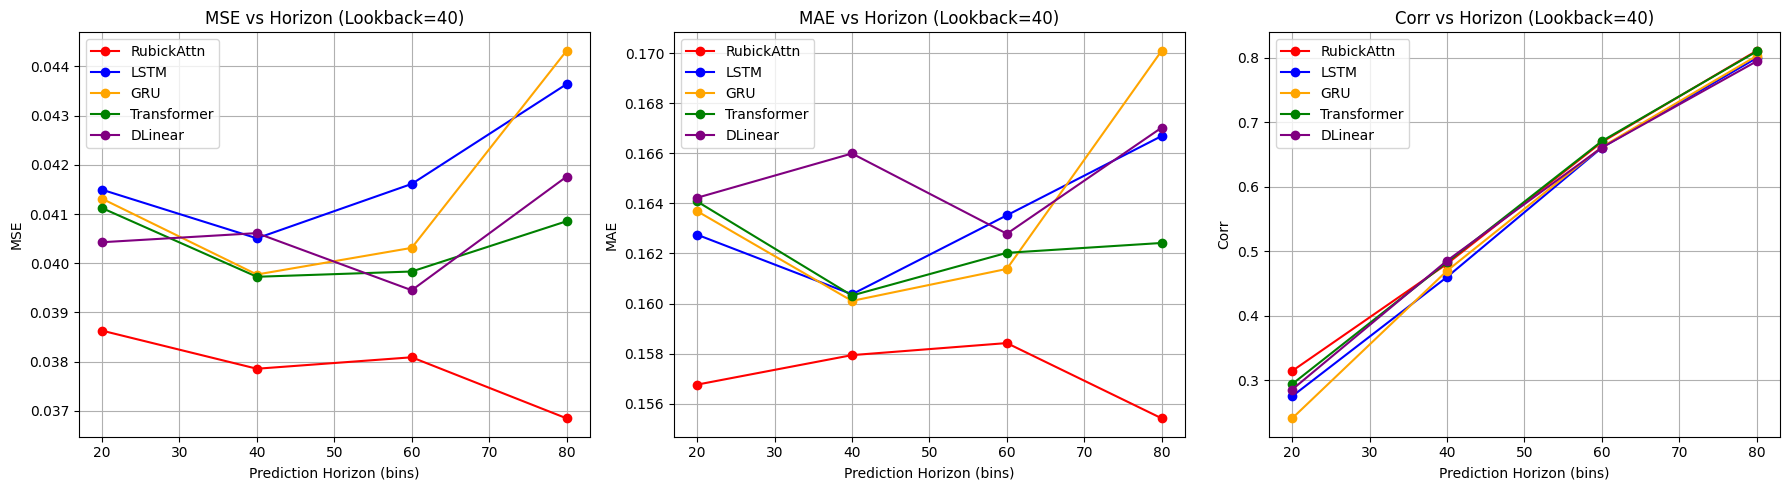

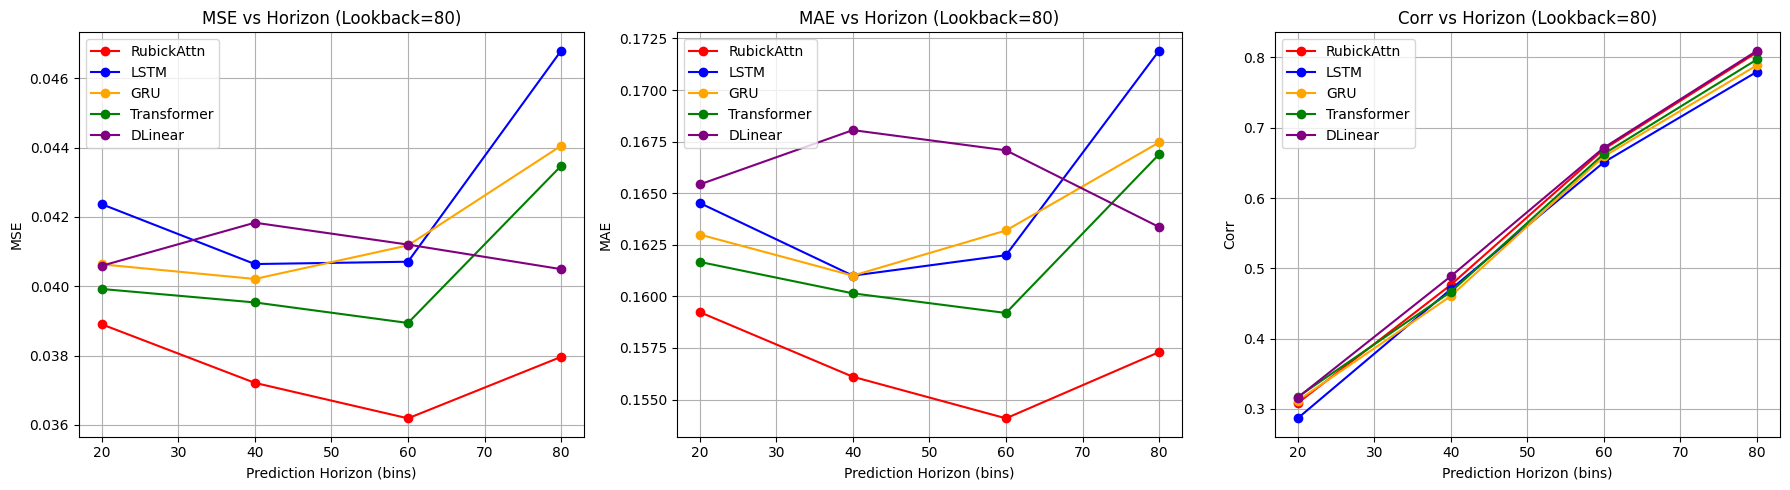

In [12]:
# =====================================================================
#  Updated summary table & plots (5‑tuple results: mse, mae, corr, params, size_mb)
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt

rows = []
for (L, H, model), (mse, mae, corr, n_params, size_mb) in results.items():
    rows.append([L, H, model, mse, mae, corr, n_params, size_mb])

df = pd.DataFrame(rows, columns=['Lookback', 'Horizon', 'Model', 'MSE', 'MAE', 'Corr', 'Params', 'Size_MB'])
print("\n===== Full Results Table =====")

# Pivot tables for metrics and model size
display(df.pivot_table(index=['Lookback', 'Horizon'], columns='Model',
                       values=['MSE', 'MAE', 'Corr']))
display(df.pivot_table(index=['Lookback', 'Horizon'], columns='Model',
                       values=['Params', 'Size_MB']))

# Save to CSV
df.to_csv('gene_expression_forecasting_results.csv', index=False)
print("Results saved to gene_expression_forecasting_results.csv")

# Plot MSE/MAE/Corr vs Horizon for each lookback window
for input_len in input_len_options:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['MSE', 'MAE', 'Corr']
    colors = {'RubickAttn': 'red', 'LSTM': 'blue', 'GRU': 'orange', 'Transformer': 'green', 'DLinear': 'purple'}

    for ax, metric in zip(axes, metrics):
        for model in ['RubickAttn', 'LSTM', 'GRU', 'Transformer', 'DLinear']:
            x_vals = []
            y_vals = []
            for H in pred_len_options:
                if (input_len, H, model) in results:
                    # results tuple: (mse, mae, corr, params, size_mb)
                    idx = {'MSE': 0, 'MAE': 1, 'Corr': 2}[metric]
                    y_vals.append(results[(input_len, H, model)][idx])
                    x_vals.append(H)
            ax.plot(x_vals, y_vals, marker='o', color=colors[model], label=model)
        ax.set_title(f'{metric} vs Horizon (Lookback={input_len})')
        ax.set_xlabel('Prediction Horizon (bins)')
        ax.set_ylabel(metric)
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()